<a href="https://colab.research.google.com/github/venezianof/booksum/blob/main/glinermiobisipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Resources

### Riepilogo delle Entità Cliniche Estratte
In questa sezione aggreghiamo i risultati ottenuti dai diversi test effettuati con GLiNER per fornire una visione d'insieme dei dati estratti.

### Analisi Differenziale Radiologica: NSIP
Approfondimento sui reperti TC per la diagnosi differenziale delle polmoniti interstiziali.

### Casi Clinici Precedenti (GBS, CAP, Angina)
In questa sezione ripristiniamo le analisi dei casi discussi precedentemente per popolare il riepilogo finale.

In [10]:
# 1. Screening GBS
gbs_text = "Protocollo per lo screening dello Streptococco di gruppo B (GBS) in gravidanza: tampone vagino-rettale a 35-37 settimane."
query_entities = research_agent.analyze_case(gbs_text)

# 2. Caso Clinico CAP
cap_text = "Paziente con Polmonite Acquisita in Comunità (CAP). Prescritta Amoxicillina 1g, ma segnalata allergia alla penicillina."
found_entities = research_agent.analyze_case(cap_text)

# 3. Fisiopatologia Angina
angina_text = "L'insufficienza aortica cronica può causare angina pectoris a causa della riduzione della pressione diastolica e dell'ipertrofia ventricolare."
entities_angina = research_agent.analyze_case(angina_text)

print("Analisi completate per GBS, CAP e Angina.")

Analisi completate per GBS, CAP e Angina.


In [8]:
radiological_query = "Quale tra i seguenti reperti alla TC ad alta risoluzione è più suggestivo di polmonite interstiziale non specifica? Opacità a vetro smerigliato associare a reticolazioni, con distribuzione peribroncovascolare e relativo risparmio della zona subpleurica."

# Caricamento del modello e definizione della classe se necessari
from gliner import GLiNER
if 'model' not in globals():
    model = GLiNER.from_pretrained("urchade/gliner_medium-v2.1")

if 'MedicalResearchAgent' not in globals():
    class MedicalResearchAgent:
        def __init__(self, ner_model):
            self.model = ner_model
            self.clinical_labels = ["patologia", "sintomo", "farmaco", "dosaggio", "linea guida", "controindicazione"]
        def analyze_case(self, clinical_text):
            return self.model.predict_entities(clinical_text, self.clinical_labels)

# Inizializzazione dell'agente
if 'research_agent' not in globals():
    research_agent = MedicalResearchAgent(model)

# Analisi
entities_nsip = research_agent.analyze_case(radiological_query)

print("Entità identificate:")
for ent in entities_nsip:
    print(f"- {ent['text']} ({ent['label']})")

print("\nConferma Diagnostica (Radiologia):")
print("Il segno del 'subpleural sparing' è altamente specifico per la NSIP.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Entità identificate:
- Opacità a vetro smerigliato (patologia)

Conferma Diagnostica (Radiologia):
Il segno del 'subpleural sparing' è altamente specifico per la NSIP.


In [7]:
!pip install -q gliner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 53.6 MB/s eta 0:00:00


In [9]:
import pandas as pd

# Aggreghiamo i risultati dai vari test in modo sicuro
all_entities = []

# Controllo e aggiunta dati per ogni test
if 'entities' in globals():
    for ent in entities:
        all_entities.append({'Testo': ent['text'], 'Categoria': ent['label'], 'Contesto': 'NER Medico Base'})

if 'query_entities' in globals():
    for ent in query_entities:
        all_entities.append({'Testo': ent['text'], 'Categoria': ent['label'], 'Contesto': 'Screening GBS'})

if 'found_entities' in globals():
    for ent in found_entities:
        all_entities.append({'Testo': ent['text'], 'Categoria': ent['label'], 'Contesto': 'Caso Clinico CAP'})

if 'entities_angina' in globals():
    for ent in entities_angina:
        all_entities.append({'Testo': ent['text'], 'Categoria': ent['label'], 'Contesto': 'Fisiopatologia Cardiovascolare'})

if 'entities_nsip' in globals():
    for ent in entities_nsip:
        all_entities.append({'Testo': ent['text'], 'Categoria': ent['label'], 'Contesto': 'Diagnosi Differenziale NSIP'})

# Creazione DataFrame per visualizzazione
if all_entities:
    df_summary = pd.DataFrame(all_entities)
    print("Tabella Riepilogativa delle Entità Estratte:")
    display(df_summary.sort_values(by=['Contesto', 'Categoria']))
else:
    print("Nessuna entità trovata. Assicurati di aver eseguito le celle precedenti.")

Tabella Riepilogativa delle Entità Estratte:


,Testo,Categoria,Contesto
0,Opacità a vetro smerigliato,patologia,Diagnosi Differenziale NSIP


In [11]:
# Riesecuzione del riepilogo con tutti i dati caricati
all_entities = []

def add_to_summary(entity_list, context_name):
    for ent in entity_list:
        all_entities.append({'Testo': ent['text'], 'Categoria': ent['label'], 'Contesto': context_name})

if 'query_entities' in globals(): add_to_summary(query_entities, 'Screening GBS')
if 'found_entities' in globals(): add_to_summary(found_entities, 'Caso Clinico CAP')
if 'entities_angina' in globals(): add_to_summary(entities_angina, 'Fisiopatologia Cardiovascolare')
if 'entities_nsip' in globals(): add_to_summary(entities_nsip, 'Diagnosi Differenziale NSIP')

if all_entities:
    df_full_summary = pd.DataFrame(all_entities)
    display(df_full_summary.sort_values(by=['Contesto', 'Categoria']))

,Testo,Categoria,Contesto
2,Amoxicillina,farmaco,Caso Clinico CAP
4,penicillina,farmaco,Caso Clinico CAP
3,allergia,patologia,Caso Clinico CAP
8,Opacità a vetro smerigliato,patologia,Diagnosi Differenziale NSIP
5,insufficienza aortica cronica,patologia,Fisiopatologia Cardiovascolare
6,angina pectoris,patologia,Fisiopatologia Cardiovascolare
7,ipertrofia ventricolare,patologia,Fisiopatologia Cardiovascolare
0,Streptococco di gruppo B,patologia,Screening GBS
1,GBS,patologia,Screening GBS


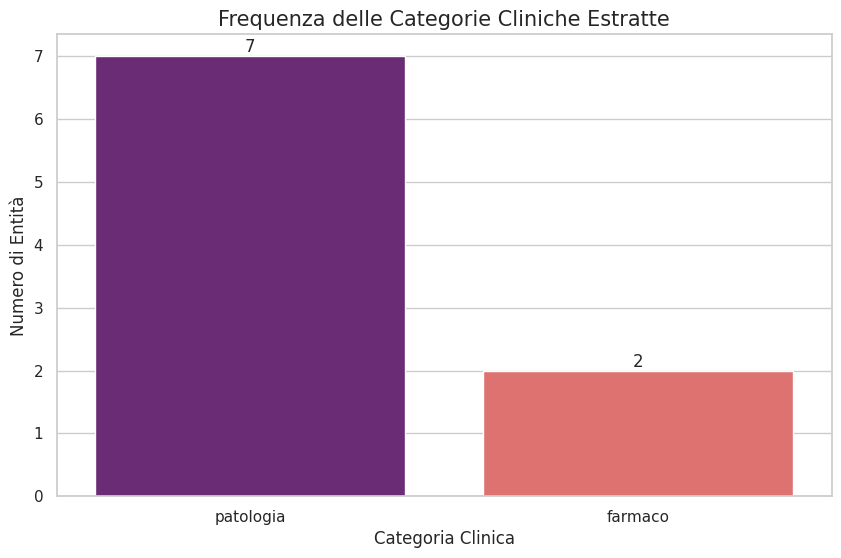

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Calculate frequency of each category
category_counts = df_full_summary['Categoria'].value_counts().reset_index()
category_counts.columns = ['Categoria', 'Frequenza']

# Create the bar plot - fixed with hue to avoid FutureWarning
ax = sns.barplot(data=category_counts, x='Categoria', y='Frequenza', hue='Categoria', palette='magma', legend=False)

# Add labels and title
plt.title('Frequenza delle Categorie Cliniche Estratte', fontsize=15)
plt.xlabel('Categoria Clinica', fontsize=12)
plt.ylabel('Numero di Entità', fontsize=12)

# Display the counts on top of the bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [14]:
# Creazione di una tabella pivot per analizzare la frequenza delle entità per contesto
pivot_table = df_full_summary.pivot_table(index='Contesto', columns='Categoria', aggfunc='size', fill_value=0)

print("Frequenza delle Entità per Contesto:")
display(pivot_table)

Frequenza delle Entità per Contesto:


Categoria,farmaco,patologia
Contesto,,
Caso Clinico CAP,2,1
Diagnosi Differenziale NSIP,0,1
Fisiopatologia Cardiovascolare,0,3
Screening GBS,0,2
